# Exploratory data analysis — Car damage severity

**Goal:** Understand class balance, file layout, and image properties before modeling.

**Before you run:** Set `DATA_ROOT` to the folder that contains your split directories. The notebook accepts **`train` / `test`** or **`training` / `testing`** (each with `minor`, `moderate`, `severe` subfolders).

**Outputs:** A table of counts per class, optional CSV under `data/`, and plots.

In [11]:
from __future__ import annotations

import os
from collections import defaultdict
from pathlib import Path

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# --- Set this to your dataset root (folder containing "train" and "test") ---
DATA_ROOT = Path(r"C:\D_Folder\Defect seviority dataset\dataset")  # <-- change this

# Where to save the summary CSV (created automatically)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUT_DIR = PROJECT_ROOT / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif"}


def resolve_split_dir(root: Path, *candidates: str) -> Path:
    """Use first existing subdirectory among candidates (e.g. train vs training)."""
    for name in candidates:
        p = root / name
        if p.is_dir():
            return p
    return root / candidates[0]


print("DATA_ROOT:", DATA_ROOT.resolve())

DATA_ROOT: C:\D_Folder\Defect seviority dataset\dataset


In [12]:
def list_images_per_class(split_root: Path) -> dict[str, list[Path]]:
    """Expect split_root / class_name / *.images"""
    out: dict[str, list[Path]] = {}
    if not split_root.is_dir():
        return out
    for class_dir in sorted(split_root.iterdir()):
        if not class_dir.is_dir():
            continue
        name = class_dir.name
        files = [
            p
            for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
        out[name] = files
    return out


def counts_to_dataframe(split_name: str, per_class: dict[str, list[Path]]) -> pd.DataFrame:
    rows = []
    for cls, paths in sorted(per_class.items()):
        rows.append({"split": split_name, "class": cls, "count": len(paths)})
    # Empty rows => DataFrame with no columns without explicit columns= — breaks groupby("split") later
    return pd.DataFrame(rows, columns=["split", "class", "count"])


def try_image_size(path: Path) -> tuple[int, int] | None:
    try:
        with Image.open(path) as im:
            w, h = im.size
        return (w, h)
    except Exception as e:
        print(f"Unreadable: {path} ({e})")
        return None

In [16]:
train_root = resolve_split_dir(DATA_ROOT, "train", "training")
test_root = resolve_split_dir(DATA_ROOT, "test", "testing")

train_map = list_images_per_class(train_root)
test_map = list_images_per_class(test_root)

df_train = counts_to_dataframe("train", train_map)
df_test = counts_to_dataframe("test", test_map)
df_all = pd.concat([df_train, df_test], ignore_index=True)

if not df_all.empty:
    df_all["count"] = pd.to_numeric(df_all["count"], errors="coerce").fillna(0).astype("int64")

n_img = int(df_all["count"].sum()) if not df_all.empty else 0
if n_img == 0:
    print("No images found under: DATA_ROOT/(train|training)/<class>/ and DATA_ROOT/(test|testing)/<class>/")
    print("DATA_ROOT =", DATA_ROOT.resolve())
    if DATA_ROOT.is_dir():
        print("Contents of DATA_ROOT:", [p.name for p in DATA_ROOT.iterdir()])

# Fraction within each split (numeric dtypes — empty frame with explicit columns was object and broke .round)
totals = df_all.groupby("split")["count"].transform("sum")
den = totals.replace(0, np.nan).astype("float64")
num = df_all["count"].astype("float64")
df_all["fraction"] = (num / den).round(4)

# #region agent log
_DBG = PROJECT_ROOT / "debug-75a486.log"
with open(_DBG, "a", encoding="utf-8") as _f:
    _f.write(
        json.dumps(
            {
                "sessionId": "75a486",
                "hypothesisId": "verify",
                "location": "Defect seviority.ipynb:counts_cell",
                "message": "post_fix_paths_and_dtypes",
                "data": {
                    "train_root": str(train_root),
                    "test_root": str(test_root),
                    "n_img": n_img,
                    "count_dtype": str(df_all["count"].dtype) if not df_all.empty else None,
                    "fraction_dtype": str(df_all["fraction"].dtype) if not df_all.empty else None,
                },
                "timestamp": int(time.time() * 1000),
            }
        )
        + "\n"
    )
# #endregion

display(df_all)

csv_path = OUT_DIR / "class_counts.csv"
df_all.to_csv(csv_path, index=False)
print("Saved:", csv_path.resolve())

,split,class,count,fraction
0,train,01-minor,452,0.3268
1,train,02-moderate,463,0.3348
2,train,03-severe,468,0.3384
3,test,01-minor,82,0.3306
4,test,02-moderate,75,0.3024
5,test,03-severe,91,0.3669


Saved: C:\D_Folder\python_projects\Defect severity prediction\data\class_counts.csv


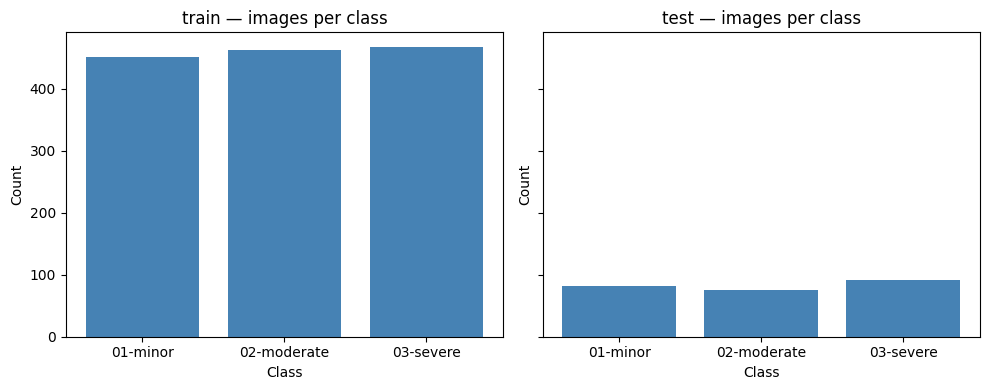

train: max/min class count ratio = 1.04
test: max/min class count ratio = 1.21


In [17]:
# Bar chart: class counts per split
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, split in zip(axes, ["train", "test"]):
    sub = df_all[df_all["split"] == split].sort_values("class")
    ax.bar(sub["class"], sub["count"], color="steelblue")
    ax.set_title(f"{split} — images per class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Imbalance ratio (max count / min count) per split — quick scalar summary
for split in ["train", "test"]:
    sub = df_all[df_all["split"] == split]["count"]
    if len(sub) == 0:
        continue
    ratio = sub.max() / sub.min() if sub.min() > 0 else float("inf")
    print(f"{split}: max/min class count ratio = {ratio:.2f}")

In [18]:
# Sample image widths/heights (first up to N images per class per split; adjust if slow)
MAX_PER_CLASS = 200

def sample_sizes(split_name: str, per_class: dict[str, list[Path]]) -> pd.DataFrame:
    rows = []
    for cls, paths in sorted(per_class.items()):
        for p in paths[:MAX_PER_CLASS]:
            wh = try_image_size(p)
            if wh is None:
                continue
            w, h = wh
            rows.append(
                {
                    "split": split_name,
                    "class": cls,
                    "width": w,
                    "height": h,
                    "path": str(p),
                }
            )
    return pd.DataFrame(rows)

df_sizes_train = sample_sizes("train", train_map)
df_sizes_test = sample_sizes("test", test_map)
df_sizes = pd.concat([df_sizes_train, df_sizes_test], ignore_index=True)

if not df_sizes.empty:
    df_sizes["megapixels"] = (df_sizes["width"] * df_sizes["height"]) / 1e6
    display(df_sizes.groupby("split")[["width", "height", "megapixels"]].describe())
else:
    print("No images found — check DATA_ROOT and folder names.")

width                                                           height  \
       count        mean        std   min     25%    50%    75%    max  count   
split                                                                           
test   248.0  236.391129  62.416294  89.0  201.50  259.0  275.0  420.0  248.0   
train  600.0  252.968333  40.298809  98.0  251.75  259.0  275.0  411.0  600.0   

                   ...               megapixels                                \
             mean  ...    75%    max      count      mean       std       min   
split              ...                                                          
test   171.116935  ...  194.0  282.0      248.0  0.041888  0.015061  0.007654   
train  183.996667  ...  194.0  306.0      600.0  0.046552  0.009368  0.011660   

                                               
            25%       50%       75%       max  
split                                          
test   0.046474  0.050246  0.050345  0.050625  
train  0.050246  0.050246  0.050400  0.050625  

[2 rows x 24 columns]

### What to do with these results

1. **Class imbalance:** If max/min ratio is large, plan for **macro F1**, **class weights**, or **oversampling** minority classes.
2. **Train vs test:** Compare **fractions** across splits; big shifts mean test metrics need careful interpretation.
3. **Resolution:** Wide spread in width/height supports **resize + center crop** (as in your pipeline) so batches are fixed-size.
4. **Next:** Stratified **train/val** split from `train` only; keep Kaggle `test` for final evaluation.